# Pipeline de Clasificación Retórica IMRaD — Etapa 1

Este notebook ejecuta paso a paso el pipeline de clasificación de fragmentos de artículos científicos en español según su función retórica IMRaD:
- **Introducción** (0)
- **Metodología** (1)
- **Resultados** (2)
- **Discusión** (3)

**Modelos evaluados:**
- **SciBETO-large** (`Flaglab/SciBETO-large`) — fine-tuning supervisado
- **Qwen2.5:3b** (Ollama) — zero-shot y few-shot

**Datos mock:** PubMed 200k RCT traducido al español con MarianMT

---
## Paso 0 — Configuración del entorno

In [1]:
import os
import sys
from pathlib import Path

# Agregar raíz del proyecto al path
PROJECT_ROOT = Path(".").resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Habilitar fallback MPS para operaciones no soportadas en Apple Silicon
os.environ.setdefault("PYTORCH_ENABLE_MPS_FALLBACK", "1")

print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"Python: {sys.version}")

PROJECT_ROOT: /Users/wflor/Documents/uniandes/proyectoFinal/Pry-ScienceDocsSpanish
Python: 3.9.6 (default, Mar  6 2026, 16:22:43) 
[Clang 21.0.0 (clang-2100.0.123.102)]


In [2]:
import torch
import transformers
import datasets

print(f"PyTorch:      {torch.__version__}")
print(f"Transformers: {transformers.__version__}")
print(f"Datasets:     {datasets.__version__}")
print(f"MPS available: {torch.backends.mps.is_available()}")
print(f"CUDA available: {torch.cuda.is_available()}")

/Users/wflor/Documents/uniandes/proyectoFinal/Pry-ScienceDocsSpanish/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/wflor/Documents/uniandes/proyectoFinal/Pry-ScienceDocsSpanish/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch:      2.8.0
Transformers: 4.57.6
Datasets:     4.5.0
MPS available: True
CUDA available: False


In [3]:
from src.config import load_data_config, load_labels_config, load_models_config, get_label_id2name
from src.models.device import get_device, device_info

# Seleccionar dispositivo
device = get_device()
info = device_info(device)
print(f"Dispositivo: {info}")

# Cargar configs
data_cfg   = load_data_config()
labels_cfg = load_labels_config()
models_cfg = load_models_config()

LABEL_NAMES = get_label_id2name(labels_cfg)
print(f"\nEtiquetas IMRaD: {LABEL_NAMES}")

Dispositivo: {'device': 'mps', 'pytorch_version': '2.8.0', 'mps_available': True, 'mps_built': True}

Etiquetas IMRaD: {0: 'Introducción', 1: 'Metodología', 2: 'Resultados', 3: 'Discusión'}


---
## Paso 1 — Descarga del dataset PubMed 200k RCT

Descarga el dataset desde HuggingFace y lo almacena en caché local (`data/raw/`).
Las ejecuciones posteriores cargan desde disco sin volver a descargar.

In [4]:
from src.data.download import download_pubmed_rct, get_dataset_info
from src.config import resolve_path

raw_dir = resolve_path(data_cfg["data"]["paths"]["raw"])

dataset = download_pubmed_rct(
    raw_dir=raw_dir,
    split=data_cfg["data"]["source_split"],
    force_redownload=False,
)

info = get_dataset_info(dataset)
print(f"Total ejemplos: {info['total_examples']:,}")
print(f"Columnas: {info['columns']}")
print(f"\nDistribución de etiquetas PubMed:")
pubmed_names = labels_cfg["pubmed_label_names"]
for label_id, count in sorted(info['label_distribution'].items()):
    pct = count / info['total_examples'] * 100
    print(f"  {label_id} ({pubmed_names[label_id]:<12}): {count:>6,}  ({pct:.1f}%)")

Total ejemplos: 2,211,861
Columnas: ['labels', 'text', 'uid']

Distribución de etiquetas PubMed:
  0 (BACKGROUND  ): 196,689  (8.9%)
  1 (CONCLUSIONS ): 339,714  (15.4%)
  2 (METHODS     ): 722,586  (32.7%)
  3 (OBJECTIVE   ): 186,601  (8.4%)
  4 (RESULTS     ): 766,271  (34.6%)


In [5]:
# Inspeccionar ejemplos
print("Ejemplo del dataset (primeras 3 filas):")
for i in range(3):
    ex = dataset[i]
    label_name = pubmed_names[ex['labels']]
    print(f"\n[{i}] label={ex['labels']} ({label_name})")
    print(f"     text: {ex['text'][:150]}...")

Ejemplo del dataset (primeras 3 filas):

[0] label=0 (BACKGROUND)
     text: The emergence of HIV as a chronic condition means that people living with HIV are required to take more responsibility for the self-management of thei...

[1] label=0 (BACKGROUND)
     text: This paper describes the design and evaluation of Positive Outlook , an online program aiming to enhance the self-management skills of gay men living ...

[2] label=2 (METHODS)
     text: This study is designed as a randomised controlled trial in which men living with HIV in Australia will be assigned to either an intervention group or ...


---
## Paso 2 — Preprocesamiento y muestreo balanceado

- Mapea etiquetas PubMed (0-4) a etiquetas IMRaD (0-3)
- Limpia el texto
- Samplea **200 ejemplos por etiqueta IMRaD** (800 total)

In [7]:
import importlib
import src.data.preprocessing
importlib.reload(src.data.preprocessing)
from src.data.preprocessing import map_pubmed_labels_to_imrad, preprocess_dataset, sample_balanced, IMRAD_LABEL_NAMES
from collections import Counter

# 1. Mapear etiquetas
dataset = map_pubmed_labels_to_imrad(dataset)
print("Etiquetas PubMed mapeadas a IMRaD")

# 2. Limpiar textos
dataset = preprocess_dataset(dataset)
print("Textos limpiados")

# 3. Muestreo balanceado
examples_per_label = data_cfg["data"]["examples_per_imrad_label"]
seed = data_cfg["data"]["random_seed"]

balanced = sample_balanced(dataset, examples_per_label=examples_per_label, seed=seed)
print(f"\nDataset balanceado: {len(balanced)} ejemplos")

counts = Counter(balanced["imrad_label"])
print("\nDistribución por etiqueta IMRaD:")
for idx in range(4):
    print(f"  {idx} ({IMRAD_LABEL_NAMES[idx]:<15}): {counts[idx]}")

Mapeando etiquetas PubMed→IMRaD: 100%|██████████| 2211861/2211861 [00:29<00:00, 75229.10 examples/s]


Etiquetas PubMed mapeadas a IMRaD


Limpiando textos: 100%|██████████| 2211861/2211861 [00:37<00:00, 58844.39 examples/s]


Textos limpiados

Dataset balanceado: 800 ejemplos

Distribución por etiqueta IMRaD:
  0 (Introducción   ): 200
  1 (Metodología    ): 200
  2 (Resultados     ): 200
  3 (Discusión      ): 200


---
## Paso 3 — Traducción inglés a español (MarianMT)

Traduce los textos usando `Helsinki-NLP/opus-mt-en-es`.
Las traducciones se guardan en caché en `data/processed/translated/`.

> Nota: esta celda puede tardar varios minutos la primera vez (~15-20 min para 800 textos en CPU).

In [8]:
from src.data.translation import MarianTranslator

translated_dir = resolve_path(data_cfg["data"]["paths"]["translated"])
batch_size = data_cfg["data"]["translation"]["batch_size"]

translator = MarianTranslator(batch_size=batch_size)

balanced_translated = translator.translate_dataset(
    balanced,
    text_column="text",
    output_column="text_es",
    save_path=translated_dir / "balanced_translated",
    force_retranslate=False,
)

print(f"\nTraducción completada: {len(balanced_translated)} ejemplos")


Traducción completada: 800 ejemplos


In [8]:
# Verificar calidad de traducción — ejemplos por etiqueta
shown = set()
for ex in balanced_translated:
    label = ex["imrad_label"]
    if label not in shown:
        shown.add(label)
        print(f"\n{IMRAD_LABEL_NAMES[label]}")
        print(f"  EN: {ex['text'][:120]}")
        print(f"  ES: {ex['text_es'][:120]}")
    if len(shown) == 4:
        break


Discusión
  EN: In an ICU population in which the mortality rate associated with standard care was 27.5 % at day 28 , the rate was reduc
  ES: En una población de UTI en la que la tasa de mortalidad asociada a la atención estándar fue de 27,5 % en el día 28 , la 

Resultados
  EN: Conventional MRI white matter scores were not different ( 7.31.7 vs. 6.91.4 , P = 0.65 ) between the hypercapnic and nor
  ES: Los puntajes convencionales de la materia blanca de la IRM no fueron diferentes (7,31.7 vs. 6,91.4 , P = 0,65 ) entre lo

Introducción
  EN: This constituted part of a wider randomized controlled trial ( RCT ) .
  ES: Esto formaba parte de un ensayo controlado aleatorizado más amplio ( ECA ) .

Metodología
  EN: Randomized , double-blind controlled clinical trial .
  ES: Ensayo clínico aleatorizado, doble ciego controlado .


---
## Paso 4 — Creación de splits (80 / 10 / 10)

Divide en train / validation / test con estratificación por etiqueta IMRaD.

In [9]:
import importlib
import src.data.splitting
importlib.reload(src.data.splitting)
from src.data.splitting import create_splits

splits_dir = resolve_path(data_cfg["data"]["paths"]["splits"])

splits = create_splits(
    balanced_translated,
    train_ratio=data_cfg["data"]["train_ratio"],
    val_ratio=data_cfg["data"]["val_ratio"],
    seed=seed,
    save_dir=splits_dir / "imrad_splits",
)

print("Splits creados:")
for split_name, split_ds in splits.items():
    c = Counter(split_ds["imrad_label"])
    dist = " | ".join(f"{IMRAD_LABEL_NAMES[i]}:{c[i]}" for i in range(4))
    print(f"  {split_name:<12}: {len(split_ds):>3} ejemplos  [{dist}]")

Splits creados:
  train       : 640 ejemplos  [Introducción:160 | Metodología:160 | Resultados:160 | Discusión:160]
  validation  :  80 ejemplos  [Introducción:20 | Metodología:20 | Resultados:20 | Discusión:20]
  test        :  80 ejemplos  [Introducción:20 | Metodología:20 | Resultados:20 | Discusión:20]


---
## Paso 5 — Fine-tuning SciBETO-large

Entrenamiento supervisado de `Flaglab/SciBETO-large` (RoBERTa-large pre-entrenado en español científico).

> Nota: aproximadamente 20-30 min en MPS para 5 épocas con 640 ejemplos de entrenamiento.

In [10]:
scibeto_cfg = models_cfg["models"]["scibeto-large"]
scibeto_dir = resolve_path("models/scibeto-large-imrad")
print(f"SciBETO config cargado. Modelo guardado en: {scibeto_dir}")
print(f"Existe modelo entrenado: {(scibeto_dir / 'model.safetensors').exists()}")

SciBETO config cargado. Modelo guardado en: /Users/wflor/Documents/uniandes/proyectoFinal/Pry-ScienceDocsSpanish/models/scibeto-large-imrad
Existe modelo entrenado: True


In [11]:
from src.models.encoder import SciBETOClassifier

# Cargar modelo previamente entrenado (5 épocas, ~25 min en MPS)
# Para re-entrenar desde cero: classifier = SciBETOClassifier(device=device, ...); classifier.train(splits)
if (scibeto_dir / "model.safetensors").exists():
    classifier = SciBETOClassifier.load(scibeto_dir, device=device)
    print(f"Modelo SciBETO cargado desde {scibeto_dir}")
else:
    print("No hay modelo guardado. Entrenando desde cero...")
    classifier = SciBETOClassifier(
        device=device,
        batch_size=scibeto_cfg["batch_size"],
        learning_rate=scibeto_cfg["learning_rate"],
        num_epochs=scibeto_cfg["num_epochs"],
        warmup_ratio=scibeto_cfg["warmup_ratio"],
        weight_decay=scibeto_cfg["weight_decay"],
        output_dir=scibeto_dir,
    )
    val_metrics = classifier.train(splits)
    print(f"Val Accuracy: {val_metrics['accuracy']:.4f}")

Modelo SciBETO cargado desde /Users/wflor/Documents/uniandes/proyectoFinal/Pry-ScienceDocsSpanish/models/scibeto-large-imrad


In [12]:
# Evaluar en test set
from src.evaluation.metrics import compute_metrics

test_texts  = list(splits["test"]["text_es"])
test_labels = list(splits["test"]["imrad_label"])

scibeto_preds = classifier.predict(test_texts)
scibeto_metrics = compute_metrics(test_labels, scibeto_preds)

print("SciBETO-large — Resultados en test:")
print(f"   Accuracy:  {scibeto_metrics['accuracy']:.4f}")
print(f"   Macro F1:  {scibeto_metrics['macro_f1']:.4f}")
print(f"   Micro F1:  {scibeto_metrics['micro_f1']:.4f}")
print(f"\n{scibeto_metrics['classification_report']}")

SciBETO-large — Resultados en test:
   Accuracy:  0.8500
   Macro F1:  0.8448
   Micro F1:  0.8500

              precision    recall  f1-score   support

Introducción       0.80      0.80      0.80        20
 Metodología       0.91      1.00      0.95        20
  Resultados       0.86      0.95      0.90        20
   Discusión       0.81      0.65      0.72        20

    accuracy                           0.85        80
   macro avg       0.85      0.85      0.84        80
weighted avg       0.85      0.85      0.84        80



---
## Paso 6 — Qwen2.5:3b — Zero-shot prompting

Clasificación sin entrenamiento usando únicamente el prompt.

> Requisito: Ollama en ejecución (`ollama serve`) con el modelo descargado (`ollama pull qwen2.5:3b`).

In [14]:
import importlib
import src.models.llm_prompting
importlib.reload(src.models.llm_prompting)
from src.models.llm_prompting import QwenPrompter

prompter_zero = QwenPrompter(
    prompt_mode="zero_shot",
    prompts_dir=resolve_path("configs/prompts"),
)

# Prueba rápida con un ejemplo
example_text = test_texts[0]
pred = prompter_zero.predict_one(example_text)
print(f"Texto: {example_text[:120]}...")
print(f"Real:     {IMRAD_LABEL_NAMES[test_labels[0]]}")
print(f"Predicho: {IMRAD_LABEL_NAMES[pred]}")

Texto: El presente estudio prueba esta hipótesis de refuerzo-reducción entre los fumadores que se preparan para dejar de fumar ...
Real:     Introducción
Predicho: Introducción


In [15]:
# Evaluar en test set completo
zero_preds = prompter_zero.predict(test_texts)
zero_metrics = compute_metrics(test_labels, zero_preds)

print("Qwen2.5:3b Zero-shot — Resultados en test:")
print(f"   Accuracy:  {zero_metrics['accuracy']:.4f}")
print(f"   Macro F1:  {zero_metrics['macro_f1']:.4f}")
print(f"   Micro F1:  {zero_metrics['micro_f1']:.4f}")
print(f"\n{zero_metrics['classification_report']}")

Qwen (zero_shot): 100%|██████████| 80/80 [00:13<00:00,  5.90it/s]

Qwen2.5:3b Zero-shot — Resultados en test:
   Accuracy:  0.6625
   Macro F1:  0.6133
   Micro F1:  0.6625

              precision    recall  f1-score   support

Introducción       0.73      0.80      0.76        20
 Metodología       0.62      0.80      0.70        20
  Resultados       0.62      0.90      0.73        20
   Discusión       1.00      0.15      0.26        20

    accuracy                           0.66        80
   macro avg       0.74      0.66      0.61        80
weighted avg       0.74      0.66      0.61        80



---
## Paso 7 — Qwen2.5:3b — Few-shot prompting

Clasificación con 4 ejemplos en el prompt (uno por etiqueta IMRaD).

In [16]:
prompter_few = QwenPrompter(
    prompt_mode="few_shot",
    prompts_dir=resolve_path("configs/prompts"),
)

few_preds = prompter_few.predict(test_texts)
few_metrics = compute_metrics(test_labels, few_preds)

print("Qwen2.5:3b Few-shot — Resultados en test:")
print(f"   Accuracy:  {few_metrics['accuracy']:.4f}")
print(f"   Macro F1:  {few_metrics['macro_f1']:.4f}")
print(f"   Micro F1:  {few_metrics['micro_f1']:.4f}")
print(f"\n{few_metrics['classification_report']}")

Qwen (few_shot): 100%|██████████| 80/80 [00:14<00:00,  5.39it/s]

Qwen2.5:3b Few-shot — Resultados en test:
   Accuracy:  0.5375
   Macro F1:  0.5167
   Micro F1:  0.5375

              precision    recall  f1-score   support

Introducción       0.50      0.70      0.58        20
 Metodología       0.59      0.80      0.68        20
  Resultados       0.67      0.30      0.41        20
   Discusión       0.44      0.35      0.39        20

    accuracy                           0.54        80
   macro avg       0.55      0.54      0.52        80
weighted avg       0.55      0.54      0.52        80



---
## Paso 7a-2 — Qwen2.5:7b — Zero-shot y Few-shot

In [17]:
qwen7b_zero = QwenPrompter(
    model='qwen2.5:7b',
    prompt_mode='zero_shot',
    prompts_dir=resolve_path('configs/prompts'),
    n_votes=1,
)
qwen25_7b_zero_preds = qwen7b_zero.predict(test_texts)
qwen25_7b_zero_metrics = compute_metrics(test_labels, qwen25_7b_zero_preds)
qwen25_7b_zero_metrics['latency'] = qwen7b_zero.latency_stats
print('Qwen2.5:7b Zero-shot')
print(f"   Accuracy:  {qwen25_7b_zero_metrics['accuracy']:.4f}")
print(f"   Macro F1:  {qwen25_7b_zero_metrics['macro_f1']:.4f}")
print(f"   Latencia:  {qwen25_7b_zero_metrics['latency']['total_s']:.2f}s total, {qwen25_7b_zero_metrics['latency']['mean_s']:.3f}s/muestra")
print(qwen25_7b_zero_metrics['classification_report'])


Qwen (zero_shot): 100%|██████████| 80/80 [00:24<00:00,  3.29it/s]

Qwen2.5:7b Zero-shot
   Accuracy:  0.7125
   Macro F1:  0.6961
   Latencia:  24.21s total, 0.303s/muestra
              precision    recall  f1-score   support

Introducción       0.82      0.90      0.86        20
 Metodología       1.00      0.65      0.79        20
  Resultados       0.51      1.00      0.68        20
   Discusión       1.00      0.30      0.46        20

    accuracy                           0.71        80
   macro avg       0.83      0.71      0.70        80
weighted avg       0.83      0.71      0.70        80



In [18]:
qwen7b_few = QwenPrompter(
    model='qwen2.5:7b',
    prompt_mode='few_shot',
    prompts_dir=resolve_path('configs/prompts'),
    n_votes=1,
)
qwen25_7b_few_preds = qwen7b_few.predict(test_texts)
qwen25_7b_few_metrics = compute_metrics(test_labels, qwen25_7b_few_preds)
qwen25_7b_few_metrics['latency'] = qwen7b_few.latency_stats
print('Qwen2.5:7b Few-shot')
print(f"   Accuracy:  {qwen25_7b_few_metrics['accuracy']:.4f}")
print(f"   Macro F1:  {qwen25_7b_few_metrics['macro_f1']:.4f}")
print(f"   Latencia:  {qwen25_7b_few_metrics['latency']['total_s']:.2f}s total, {qwen25_7b_few_metrics['latency']['mean_s']:.3f}s/muestra")
print(qwen25_7b_few_metrics['classification_report'])


Qwen (few_shot): 100%|██████████| 80/80 [00:24<00:00,  3.25it/s]

Qwen2.5:7b Few-shot
   Accuracy:  0.6625
   Macro F1:  0.6366
   Latencia:  24.48s total, 0.306s/muestra
              precision    recall  f1-score   support

Introducción       0.75      0.90      0.82        20
 Metodología       0.74      0.70      0.72        20
  Resultados       0.53      0.80      0.64        20
   Discusión       0.71      0.25      0.37        20

    accuracy                           0.66        80
   macro avg       0.68      0.66      0.64        80
weighted avg       0.68      0.66      0.64        80



---
## Paso 7b — Gemini Flash — Zero-shot y Few-shot

Evaluacion con **Gemini 2.5 Flash** y **Gemini 3 Flash Preview**.

> Requiere GEMINI_API_KEY en .env

In [19]:
import importlib
import src.models.llm_prompting
importlib.reload(src.models.llm_prompting)
from src.models.llm_prompting import GeminiPrompter

# Quick 10-sample test: Gemini 2.5 Flash
g25_test = GeminiPrompter(
    model='gemini-2.5-flash',
    prompt_mode='zero_shot',
    prompts_dir=resolve_path('configs/prompts'),
)
correct = 0
for i in range(10):
    pred = g25_test.predict_one(test_texts[i])
    real = test_labels[i]
    ok = pred == real
    correct += ok
    print(f"[{i}] Real={IMRAD_LABEL_NAMES[real]:15s} Pred={IMRAD_LABEL_NAMES[pred]:15s} {'✓' if ok else '✗'}")
print(f"\nGemini 2.5 Flash: {correct}/10 correct ({correct*10}%)")


/Users/wflor/Documents/uniandes/proyectoFinal/Pry-ScienceDocsSpanish/.venv/lib/python3.9/site-packages/google/auth/__init__.py:54: FutureWarning: You are using a Python version 3.9 past its end of life. Google will update google-auth with critical bug fixes on a best-effort basis, but not with any other fixes or features. Please upgrade your Python version, and then update google-auth.
  warnings.warn(eol_message.format("3.9"), FutureWarning)
/Users/wflor/Documents/uniandes/proyectoFinal/Pry-ScienceDocsSpanish/.venv/lib/python3.9/site-packages/google/oauth2/__init__.py:40: FutureWarning: You are using a Python version 3.9 past its end of life. Google will update google-auth with critical bug fixes on a best-effort basis, but not with any other fixes or features. Please upgrade your Python version, and then update google-auth.
  warnings.warn(eol_message.format("3.9"), FutureWarning)


[0] Real=Introducción    Pred=Introducción    ✓
[1] Real=Discusión       Pred=Discusión       ✓
[2] Real=Resultados      Pred=Discusión       ✗
[3] Real=Discusión       Pred=Resultados      ✗
[4] Real=Discusión       Pred=Discusión       ✓
[5] Real=Introducción    Pred=Introducción    ✓
[6] Real=Resultados      Pred=Resultados      ✓
[7] Real=Metodología     Pred=Metodología     ✓
[8] Real=Introducción    Pred=Introducción    ✓
[9] Real=Metodología     Pred=Metodología     ✓

Gemini 2.5 Flash: 8/10 correct (80%)


In [20]:
import importlib
import src.models.llm_prompting
importlib.reload(src.models.llm_prompting)
from src.models.llm_prompting import GeminiPrompter

gemini3_zero = GeminiPrompter(
    model='gemini-3-flash-preview',
    prompt_mode='zero_shot',
    prompts_dir=resolve_path('configs/prompts'),
    n_votes=1,
)
gemini3_zero_preds = gemini3_zero.predict(test_texts)
gemini3_zero_metrics = compute_metrics(test_labels, gemini3_zero_preds)
gemini3_zero_metrics['latency'] = gemini3_zero.latency_stats
print('Gemini 3 Flash Preview Zero-shot')
print(f"   Accuracy:  {gemini3_zero_metrics['accuracy']:.4f}")
print(f"   Macro F1:  {gemini3_zero_metrics['macro_f1']:.4f}")
print(f"   Latencia:  {gemini3_zero_metrics['latency']['total_s']:.2f}s total, {gemini3_zero_metrics['latency']['mean_s']:.3f}s/muestra")
print(gemini3_zero_metrics['classification_report'])


Gemini (zero_shot): 100%|██████████| 80/80 [03:39<00:00,  2.74s/it]

Gemini 3 Flash Preview Zero-shot
   Accuracy:  0.8500
   Macro F1:  0.8477
   Latencia:  218.93s total, 2.737s/muestra
              precision    recall  f1-score   support

Introducción       0.95      0.90      0.92        20
 Metodología       0.87      1.00      0.93        20
  Resultados       0.71      0.85      0.77        20
   Discusión       0.93      0.65      0.76        20

    accuracy                           0.85        80
   macro avg       0.86      0.85      0.85        80
weighted avg       0.86      0.85      0.85        80



In [21]:
gemini3_few = GeminiPrompter(
    model='gemini-3-flash-preview',
    prompt_mode='few_shot',
    prompts_dir=resolve_path('configs/prompts'),
    n_votes=1,
)
gemini3_few_preds = gemini3_few.predict(test_texts)
gemini3_few_metrics = compute_metrics(test_labels, gemini3_few_preds)
gemini3_few_metrics['latency'] = gemini3_few.latency_stats
print('Gemini 3 Flash Preview Few-shot')
print(f"   Accuracy:  {gemini3_few_metrics['accuracy']:.4f}")
print(f"   Macro F1:  {gemini3_few_metrics['macro_f1']:.4f}")
print(f"   Latencia:  {gemini3_few_metrics['latency']['total_s']:.2f}s total, {gemini3_few_metrics['latency']['mean_s']:.3f}s/muestra")
print(gemini3_few_metrics['classification_report'])


Gemini (few_shot): 100%|██████████| 80/80 [04:25<00:00,  3.32s/it]

Gemini 3 Flash Preview Few-shot
   Accuracy:  0.8625
   Macro F1:  0.8603
   Latencia:  265.36s total, 3.317s/muestra
              precision    recall  f1-score   support

Introducción       0.94      0.85      0.89        20
 Metodología       0.91      1.00      0.95        20
  Resultados       0.78      0.90      0.84        20
   Discusión       0.82      0.70      0.76        20

    accuracy                           0.86        80
   macro avg       0.86      0.86      0.86        80
weighted avg       0.86      0.86      0.86        80



In [22]:
gemini25_zero = GeminiPrompter(
    model="gemini-2.5-flash",
    prompt_mode="zero_shot",
    prompts_dir=resolve_path("configs/prompts"),
    n_votes=1,
)
gemini25_zero_preds = gemini25_zero.predict(test_texts)
gemini25_zero_metrics = compute_metrics(test_labels, gemini25_zero_preds)
gemini25_zero_metrics["latency"] = gemini25_zero.latency_stats

print("Gemini 2.5 Flash Zero-shot — Resultados en test:")
print(f"   Accuracy:  {gemini25_zero_metrics['accuracy']:.4f}")
print(f"   Macro F1:  {gemini25_zero_metrics['macro_f1']:.4f}")
print(f"   Latencia:  {gemini25_zero_metrics['latency']['total_s']:.2f}s total, {gemini25_zero_metrics['latency']['mean_s']:.3f}s/muestra")
print(f"\n{gemini25_zero_metrics['classification_report']}")

Gemini (zero_shot):  38%|███▊      | 30/80 [00:47<01:21,  1.64s/it]

Rate limit (intento 1), esperando 15s...


Gemini (zero_shot):  70%|███████   | 56/80 [01:46<00:50,  2.11s/it]

Rate limit (intento 1), esperando 15s...


Gemini (zero_shot): 100%|██████████| 80/80 [02:43<00:00,  2.04s/it]

Gemini 2.5 Flash Zero-shot — Resultados en test:
   Accuracy:  0.8250
   Macro F1:  0.8228
   Latencia:  163.30s total, 2.041s/muestra

              precision    recall  f1-score   support

Introducción       0.95      0.90      0.92        20
 Metodología       0.90      0.95      0.93        20
  Resultados       0.68      0.85      0.76        20
   Discusión       0.80      0.60      0.69        20

    accuracy                           0.82        80
   macro avg       0.83      0.83      0.82        80
weighted avg       0.83      0.82      0.82        80



In [23]:
gemini25_few = GeminiPrompter(
    model="gemini-2.5-flash",
    prompt_mode="few_shot",
    prompts_dir=resolve_path("configs/prompts"),
    n_votes=1,
)
gemini25_few_preds = gemini25_few.predict(test_texts)
gemini25_few_metrics = compute_metrics(test_labels, gemini25_few_preds)
gemini25_few_metrics["latency"] = gemini25_few.latency_stats

print("Gemini 2.5 Flash Few-shot — Resultados en test:")
print(f"   Accuracy:  {gemini25_few_metrics['accuracy']:.4f}")
print(f"   Macro F1:  {gemini25_few_metrics['macro_f1']:.4f}")
print(f"   Latencia:  {gemini25_few_metrics['latency']['total_s']:.2f}s total, {gemini25_few_metrics['latency']['mean_s']:.3f}s/muestra")
print(f"\n{gemini25_few_metrics['classification_report']}")

Gemini (few_shot):  26%|██▋       | 21/80 [00:48<02:33,  2.61s/it]

Rate limit (intento 1), esperando 15s...


Gemini (few_shot):  70%|███████   | 56/80 [02:47<01:35,  3.99s/it]

Rate limit (intento 1), esperando 15s...


Gemini (few_shot):  89%|████████▉ | 71/80 [03:47<00:22,  2.52s/it]

Rate limit (intento 1), esperando 15s...


Gemini (few_shot): 100%|██████████| 80/80 [04:37<00:00,  3.46s/it]

Gemini 2.5 Flash Few-shot — Resultados en test:
   Accuracy:  0.8750
   Macro F1:  0.8749
   Latencia:  277.04s total, 3.463s/muestra

              precision    recall  f1-score   support

Introducción       0.95      0.90      0.92        20
 Metodología       0.90      0.95      0.93        20
  Resultados       0.81      0.85      0.83        20
   Discusión       0.84      0.80      0.82        20

    accuracy                           0.88        80
   macro avg       0.88      0.88      0.87        80
weighted avg       0.88      0.88      0.87        80



---
## Paso 8 — Comparación de modelos y visualizaciones

In [24]:
from src.evaluation.metrics import compare_models
from src.evaluation.visualization import plot_confusion_matrix, plot_model_comparison

all_results = {
    "SciBETO-large (fine-tuned)": scibeto_metrics,
    "Qwen2.5:3b (zero-shot)": zero_metrics,
    "Qwen2.5:3b (few-shot)": few_metrics,
    "Qwen2.5:7b (zero-shot)": qwen25_7b_zero_metrics,
    "Qwen2.5:7b (few-shot)": qwen25_7b_few_metrics,
    "Gemini 2.5 Flash (zero-shot)": gemini25_zero_metrics,
    "Gemini 2.5 Flash (few-shot)": gemini25_few_metrics,
    "Gemini 3 Flash (zero-shot)": gemini3_zero_metrics,
    "Gemini 3 Flash (few-shot)": gemini3_few_metrics,
}

print(compare_models(all_results))


Modelo                           Accuracy   Macro F1
----------------------------------------------------
Gemini 2.5 Flash (few-shot)        0.8750     0.8749
Gemini 3 Flash (few-shot)          0.8625     0.8603
SciBETO-large (fine-tuned)         0.8500     0.8448
Gemini 3 Flash (zero-shot)         0.8500     0.8477
Gemini 2.5 Flash (zero-shot)       0.8250     0.8228
Qwen2.5:7b (zero-shot)             0.7125     0.6961
Qwen2.5:3b (zero-shot)             0.6625     0.6133
Qwen2.5:7b (few-shot)              0.6625     0.6366
Qwen2.5:3b (few-shot)              0.5375     0.5167


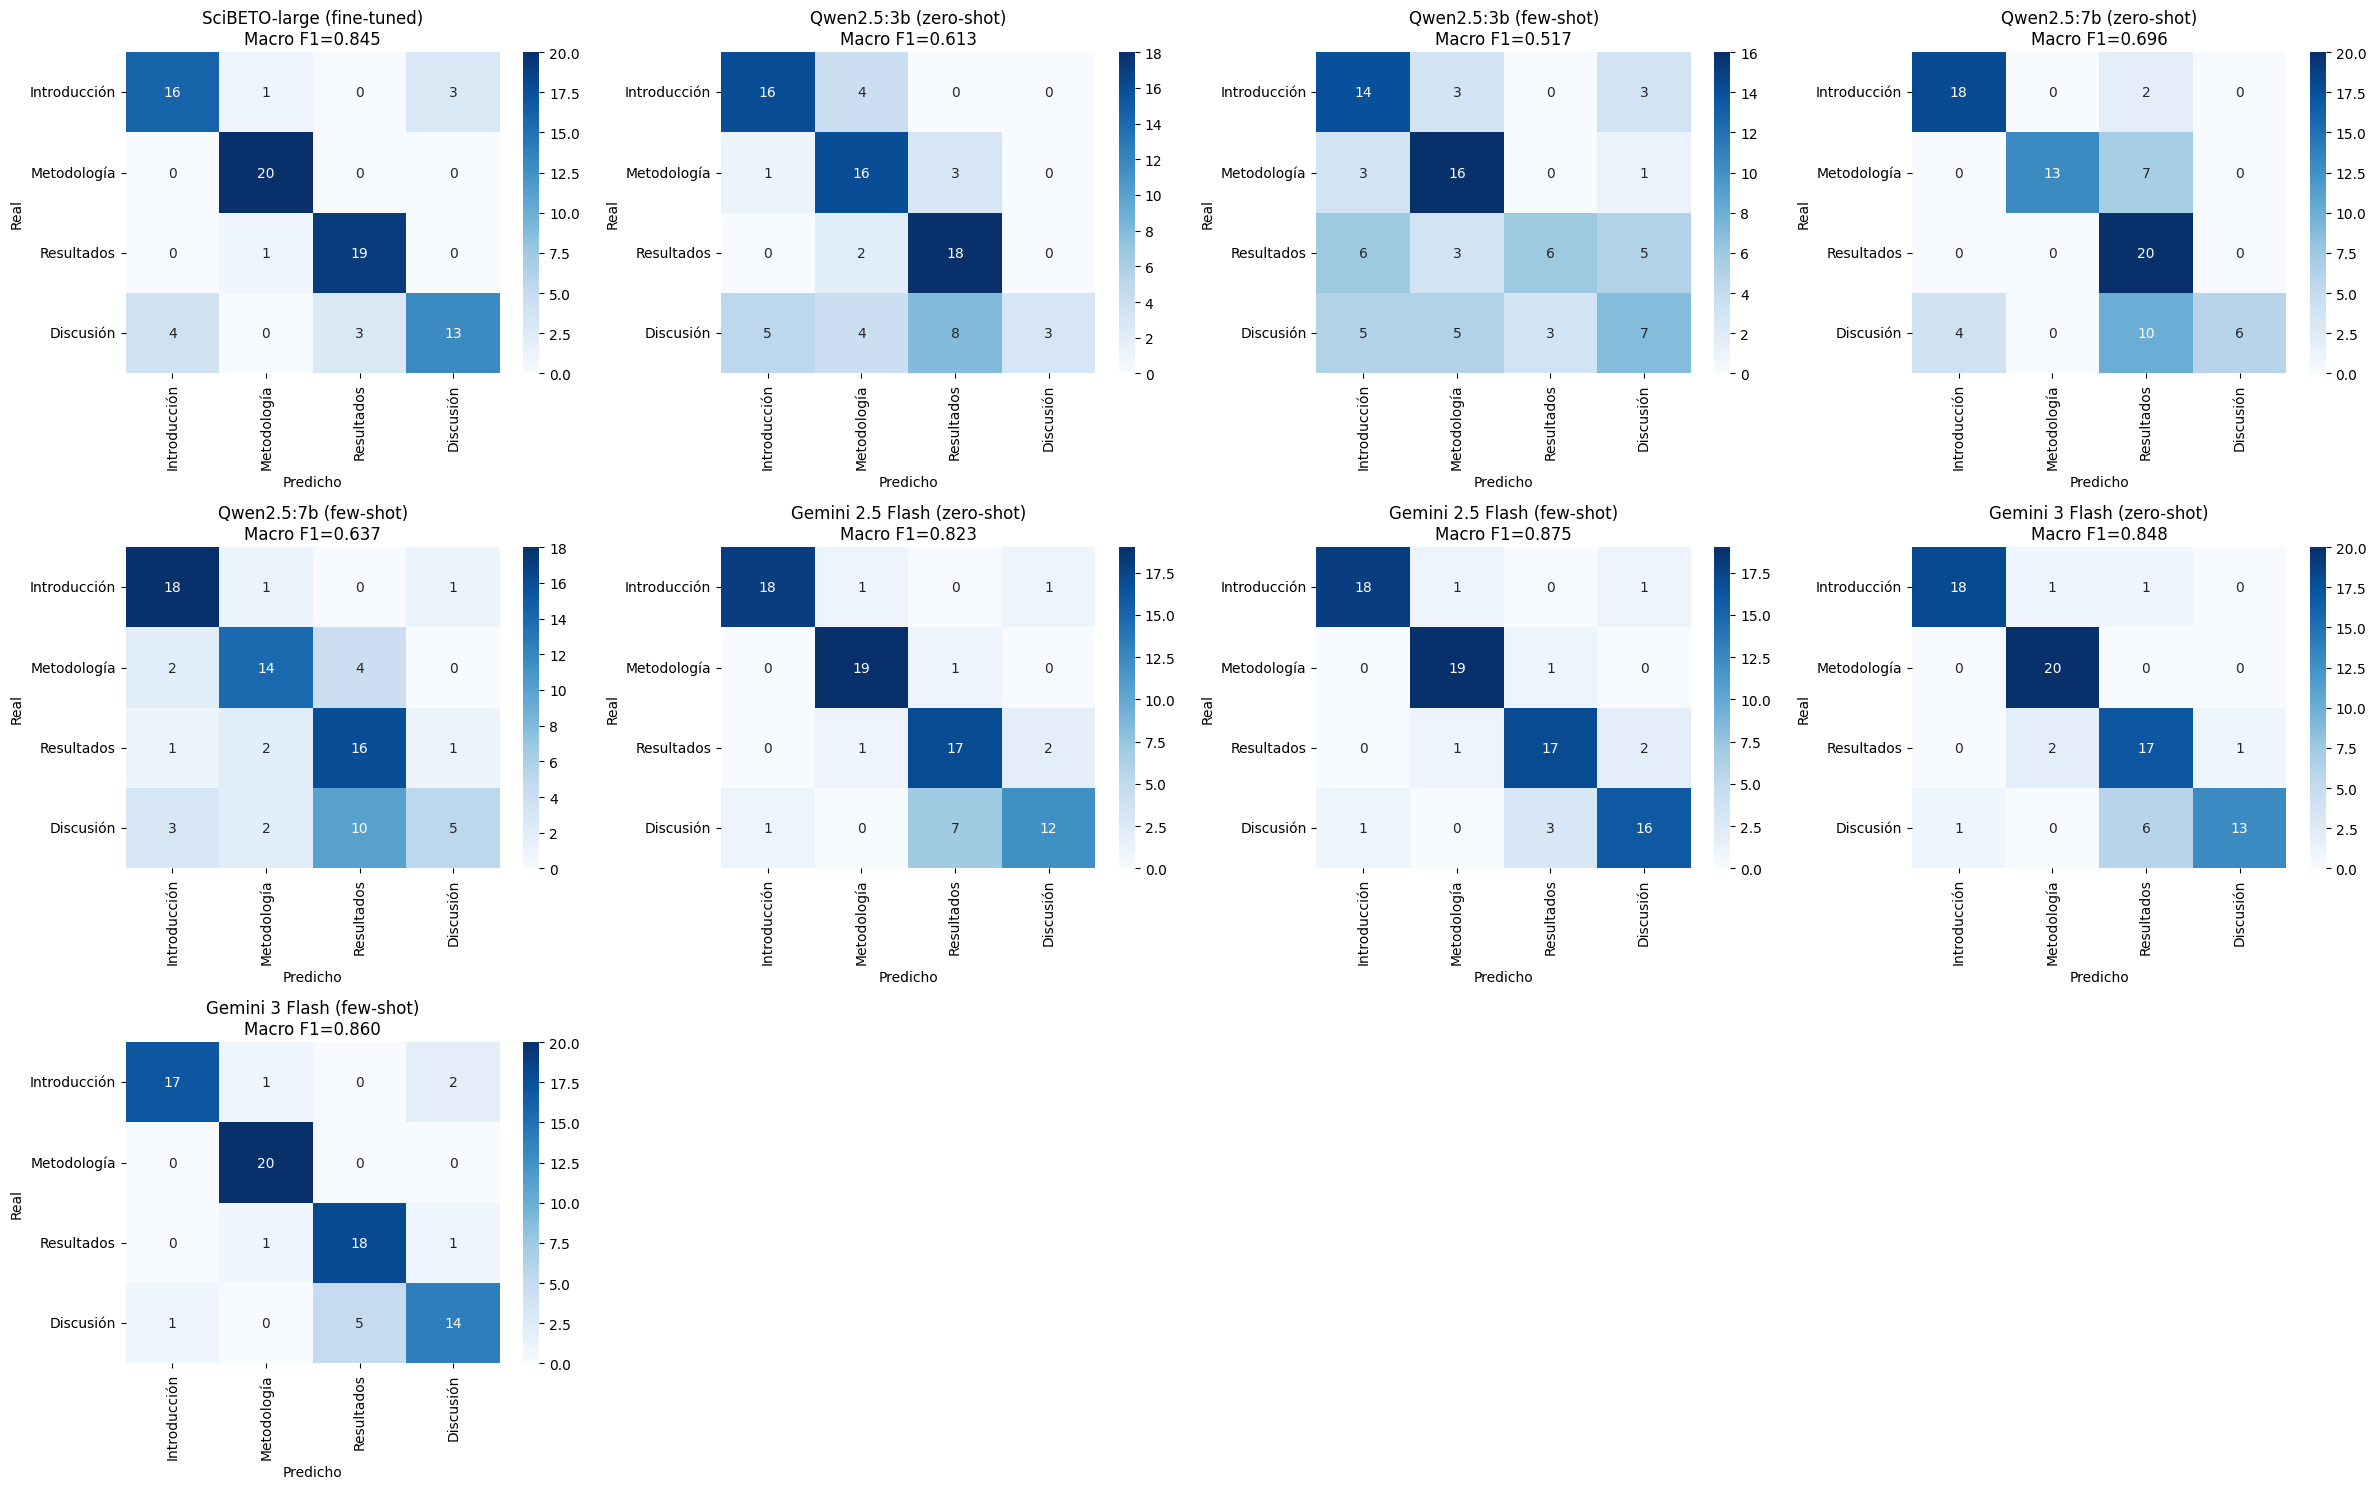

In [26]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

label_names = [IMRAD_LABEL_NAMES[i] for i in range(4)]
n_models = len(all_results)
n_cols = 4
n_rows = (n_models + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 5*n_rows))
axes_flat = axes.flatten() if n_rows > 1 else list(axes)

for i, (model_name, metrics) in enumerate(all_results.items()):
    ax = axes_flat[i]
    cm = np.array(metrics["confusion_matrix"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=label_names, yticklabels=label_names, ax=ax)
    ax.set_xlabel("Predicho")
    ax.set_ylabel("Real")
    ax.set_title(f"{model_name}\nMacro F1={metrics['macro_f1']:.3f}")

for j in range(i+1, len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.tight_layout()
plt.show()

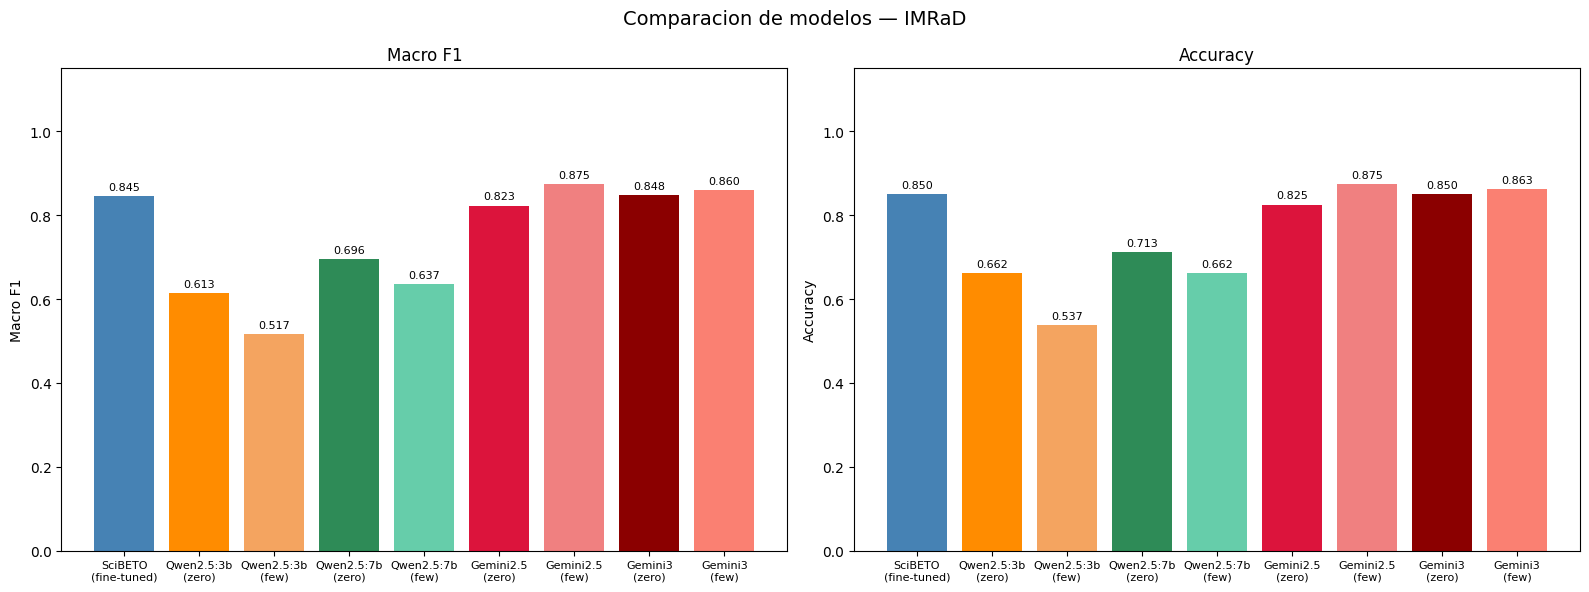

In [27]:
# Grafico comparativo de metricas
short_names = [
    "SciBETO\n(fine-tuned)",
    "Qwen2.5:3b\n(zero)", "Qwen2.5:3b\n(few)",
    "Qwen2.5:7b\n(zero)", "Qwen2.5:7b\n(few)",
    "Gemini2.5\n(zero)", "Gemini2.5\n(few)",
    "Gemini3\n(zero)", "Gemini3\n(few)",
]
colors = [
    "steelblue",
    "darkorange", "sandybrown",
    "seagreen", "mediumaquamarine",
    "crimson", "lightcoral",
    "darkred", "salmon",
]

model_names = list(all_results.keys())
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, metric in zip(axes, ["macro_f1", "accuracy"]):
    values = [all_results[m][metric] for m in model_names]
    bars = ax.bar(short_names, values, color=colors[:len(model_names)])
    ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=8)
    ax.set_ylim(0, 1.15)
    ax.set_ylabel(metric.replace("_", " ").title())
    ax.set_title(metric.replace("_", " ").title())
    ax.tick_params(axis="x", labelsize=8)

plt.suptitle("Comparacion de modelos — IMRaD", fontsize=14)
plt.tight_layout()
plt.show()


---
## Paso 9 — Guardar resultados

In [28]:
import json

reports_dir = resolve_path("reports/entrega3")
reports_dir.mkdir(parents=True, exist_ok=True)

json_results = {
    k: {kk: vv for kk, vv in v.items() if kk != "classification_report"}
    for k, v in all_results.items()
}

out_path = reports_dir / "results.json"
with open(out_path, "w", encoding="utf-8") as f:
    json.dump(json_results, f, ensure_ascii=False, indent=2)

print(f"Resultados guardados en: {out_path}")
print(json.dumps(json_results, ensure_ascii=False, indent=2)[:800])

Resultados guardados en: /Users/wflor/Documents/uniandes/proyectoFinal/Pry-ScienceDocsSpanish/reports/entrega3/results.json
{
  "SciBETO-large (fine-tuned)": {
    "accuracy": 0.85,
    "macro_f1": 0.8448,
    "micro_f1": 0.85,
    "per_class_f1": {
      "Introducción": 0.8,
      "Metodología": 0.9524,
      "Resultados": 0.9048,
      "Discusión": 0.7222
    },
    "confusion_matrix": [
      [
        16,
        1,
        0,
        3
      ],
      [
        0,
        20,
        0,
        0
      ],
      [
        0,
        1,
        19,
        0
      ],
      [
        4,
        0,
        3,
        13
      ]
    ]
  },
  "Qwen2.5:3b (zero-shot)": {
    "accuracy": 0.6625,
    "macro_f1": 0.6133,
    "micro_f1": 0.6625,
    "per_class_f1": {
      "Introducción": 0.7619,
      "Metodología": 0.6957,
      "Resultados": 0.7347,
      "Discusión": 0.2609
    },
    "confusion_matrix": [
      [
